# Serve Receive Set Prediction — Full Season Analysis
**Project:** How predictable were we in serve receive? (2025 Season)  
**Data:** 30 matches across preseason, first half conference, second half conference  
**Split:** Train on games 1–8 per period, test on games 9–10 per period

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, log_loss, ConfusionMatrixDisplay
from xgboost import XGBClassifier

from pipeline import (
    load_and_combine_games,
    build_features,
    add_attack_profiles,
    encode_target,
    get_masked_probas,
    compute_predictability,
    print_predictability_summary
)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
RANDOM_STATE = 42

# --- project config ---
FOCUS_TEAM      = "University of California, Berkeley"
FOCUS_TEAM_ID   = 249
DVW_FOLDER      = "data/dvw"
OUTPUT_FOLDER   = "data/processed"
R_SCRIPT        = "extract_serve_receive.R"

## 2. Load All Games
Loops through `data/dvw/`, runs `extract_serve_receive.R` on each file,
and combines into one DataFrame. Per-game CSVs are cached in `data/processed/`
— set `force_rerun=True` to regenerate them.

In [2]:
df_all = load_and_combine_games(
    dvw_folder      = DVW_FOLDER,
    output_folder   = OUTPUT_FOLDER,
    r_script_path   = R_SCRIPT,
    focus_team_id   = FOCUS_TEAM_ID,
    focus_team_name = FOCUS_TEAM,
    force_rerun     = False
)

print(f"\nGames loaded: {df_all['game_number'].nunique()}")
print(f"Total points: {len(df_all)}")
df_all.head()

  Loaded 01_pre_train_SDSU.dvw: 164 rows
  Loaded 02_pre_train_USF.dvw: 126 rows
  Loaded 03_pre_train_WSU.dvw: 182 rows
  Loaded 04_pre_train_UNL.dvw: 113 rows
  Loaded 05_pre_train_VANDY.dvw: 208 rows
  Loaded 06_pre_train_CPOLY.dvw: 113 rows
  Loaded 07_pre_train_SJSU.dvw: 112 rows
  Loaded 08_pre_train_DAVIS.dvw: 188 rows
  Loaded 09_pre_test_LSU.dvw: 189 rows
  Loaded 10_pre_test_USC.dvw: 155 rows
  Loaded 11_conf1_train_VT.dvw: 119 rows
  Loaded 12_conf1_train_UVA.dvw: 153 rows
  Loaded 13_conf1_train_UL.dvw: 104 rows
  Loaded 14_conf1_train_ND.dvw: 115 rows
  Loaded 15_conf1_train_CUSE.dvw: 179 rows
  Loaded 16_conf1_train_BC.dvw: 160 rows
  Loaded 17_conf1_train_MIA.dvw: 174 rows
  Loaded 18_conf1_train_FSU.dvw: 195 rows
  Loaded 19_conf1_test_GT.dvw: 149 rows
  Loaded 20_conf1_test_CLEM.dvw: 124 rows
  Loaded 21_conf2_train_WF.dvw: 127 rows
  Loaded 22_conf2_train_NCST.dvw: 162 rows
  Loaded 23_conf2_train_DUKE.dvw: 109 rows
  Loaded 24_conf2_train_UNC.dvw: 110 rows
  Loaded 2

,point_id,set_number,serving_team,receiving_team,home_team,visiting_team,home_team_id,visiting_team_id,home_setter_position,visiting_setter_position,home_p1,home_p2,home_p3,home_p4,home_p5,home_p6,visiting_p1,visiting_p2,visiting_p3,visiting_p4,visiting_p5,visiting_p6,home_player_id1,home_player_id2,home_player_id3,...,visiting_player_id5,visiting_player_id6,server_id,serve_eval_code,receiver_id,receive_eval_code,setter_id,set_code,set_type,attacker_id,attack_code,attack_eval_code,home_score_start_of_point,visiting_score_start_of_point,score_diff,point_won_by,prev_point_won,is_ace,is_overpass,out_of_system,no_set,no_attack,game_number,period,split
0,2,1,San Diego State University,"University of California, Berkeley","University of California, Berkeley",San Diego State University,249,214,5,6,15,10,55,7,12,17,7,4,10,6,11,16,-434970,-542277,-379097,...,-435730,-384309,-384307,-,-550140,#,-379094.0,KM,C,-379095.0,X1,#,2,1,1,"University of California, Berkeley",NaN,False,False,False,False,False,1,pre,train
1,3,1,"University of California, Berkeley",San Diego State University,"University of California, Berkeley",San Diego State University,249,214,4,6,4,55,7,12,17,15,7,4,10,6,11,16,-542354,-379097,-379095,...,-435730,-384309,-542354,-,-545085,+,-384309.0,K1,C,-435727.0,X1,-,2,2,0,San Diego State University,True,False,False,False,False,False,1,pre,train
2,4,1,San Diego State University,"University of California, Berkeley","University of California, Berkeley",San Diego State University,249,214,4,5,4,55,7,12,17,15,4,10,6,11,16,7,-542354,-379097,-379095,...,-384309,-384307,-552770,#,-550140,=,NaN,NaN,NaN,NaN,NaN,NaN,2,3,-1,San Diego State University,False,True,True,False,True,True,1,pre,train
3,5,1,San Diego State University,"University of California, Berkeley","University of California, Berkeley",San Diego State University,249,214,4,5,4,55,7,12,17,15,4,10,6,11,16,7,-542354,-379097,-379095,...,-384309,-384307,-552770,-,-434966,+,-379094.0,KS,C,-379095.0,CF,-,3,3,0,"University of California, Berkeley",False,False,False,False,False,False,1,pre,train
4,6,1,"University of California, Berkeley",San Diego State University,"University of California, Berkeley",San Diego State University,249,214,3,5,55,7,12,17,15,4,4,10,6,11,16,7,-379097,-379095,-379094,...,-384309,-384307,-379097,-,-384307,+,-384309.0,K7,B,-418410.0,X6,#,3,4,-1,San Diego State University,True,False,False,False,False,False,1,pre,train


## 3. Season-Level EDA

In [3]:
# points per period and split
print("Points by period and split:")
print(df_all.groupby(['period', 'split']).size().rename('points'))
print()

# special situation rates across season
print("Special situation rates:")
for flag in ['is_ace', 'is_overpass', 'out_of_system', 'no_set', 'no_attack']:
    print(f"  {flag}: {df_all[flag].sum()} ({df_all[flag].mean():.1%})")

Points by period and split:
period  split
conf1   test      273
        train    1199
conf2   test      304
        train     984
pre     test      344
        train    1206
Name: points, dtype: int64

Special situation rates:
  is_ace: 278 (6.5%)
  is_overpass: 452 (10.5%)
  out_of_system: 1743 (40.4%)
  no_set: 465 (10.8%)
  no_attack: 598 (13.9%)


In [4]:
# attacker distribution across season (who got set most?)
df_attacks = df_all[df_all['no_attack'] == False]
print("Season attack distribution by attacker_id:")
print(df_attacks['attacker_id'].value_counts())

Season attack distribution by attacker_id:
attacker_id
-379097.0    386
-379095.0    371
-542277.0    312
-550140.0    244
-441102.0    208
            ... 
-548418.0      1
-542414.0      1
-562578.0      1
-550142.0      1
-553755.0      1
Name: count, Length: 212, dtype: int64


## 4. Feature Engineering & Modeling

Each period is handled separately — preseason, first half conference,
and second half conference each get their own model trained only on
that period's games and evaluated on that period's test games.

In [8]:
FEATURES = [
    'receiving_rotation',
    'pass_quality',
    'score_diff',
    'set_number',
    'server_encoded',
    'recv_p2_enc', 'recv_p3_enc', 'recv_p4_enc',
    'recv_p1_enc', 'recv_p5_enc', 'recv_p6_enc',
    'opp_p2_enc',  'opp_p3_enc',  'opp_p4_enc',
    'player_top_attack_enc',
    'prev_point_won',
    'prev_attacker_enc',
]
TARGET = 'target'

### 4a. Preseason:

In [5]:
# PRESEASON MODEL
# Train: preseason train games | Test: preseason test games

raw_train_pre = df_all[(df_all['period'] == 'pre') & (df_all['split'] == 'train')]
raw_test_pre  = df_all[(df_all['period'] == 'pre') & (df_all['split'] == 'test')]

print(f"Preseason train games: {raw_train_pre['game_number'].nunique()}")
print(f"Preseason test games:  {raw_test_pre['game_number'].nunique()}")

Preseason train games: 8
Preseason test games:  2


In [6]:
# build features — encoders fit on preseason training data only
train_pre, encoders_pre = build_features(raw_train_pre, focus_team=FOCUS_TEAM)
test_pre,  _            = build_features(
    raw_test_pre,
    focus_team = FOCUS_TEAM,
    le_server  = encoders_pre['server'],
    le_player  = encoders_pre['player'],
    le_prev    = encoders_pre['prev']
)

Rows where University of California, Berkeley is receiving (with attack): 535
Rows where University of California, Berkeley is receiving (with attack): 160


In [9]:
# encode target and attack profiles from preseason training only
train_pre, le_pre = encode_target(train_pre, train_pre)
test_pre,  _      = encode_target(test_pre,  train_pre)

train_pre, _ = add_attack_profiles(train_pre, train_pre)
test_pre,  _ = add_attack_profiles(test_pre,  train_pre)

# drop NaN and build X/y
train_pre = train_pre.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
test_pre  = test_pre.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

X_train_pre, y_train_pre = train_pre[FEATURES], train_pre[TARGET].astype(int)
X_test_pre,  y_test_pre  = test_pre[FEATURES],  test_pre[TARGET].astype(int)

print(f"Preseason train rows: {len(X_train_pre)}")
print(f"Preseason test rows:  {len(X_test_pre)}")

Note: 1 attacker(s) unseen in training: {'-513686'}
Preseason train rows: 535
Preseason test rows:  155


In [11]:
# train preseason model
model_pre = XGBClassifier(
    n_estimators  = 200,
    max_depth     = 4,
    learning_rate = 0.05,
    subsample     = 0.8,
    eval_metric   = 'mlogloss',
    random_state  = RANDOM_STATE
)
model_pre.fit(X_train_pre, y_train_pre, eval_set=[(X_test_pre, y_test_pre)], verbose=False)
print("Preseason model trained.")

Preseason model trained.


In [12]:
# evaluate preseason model on test games
proba_test_pre    = get_masked_probas(test_pre, model_pre, FEATURES, le_pre)
y_pred_pre        = le_pre.classes_[np.argmax(proba_test_pre.values, axis=1)]
y_pred_labels_pre = le_pre.transform(y_pred_pre.astype(str))

present_labels_pre = sorted(set(y_test_pre) | set(y_pred_labels_pre))
present_names_pre  = [f"player_{le_pre.classes_[i]}" for i in present_labels_pre]

print("=== Preseason Test Performance ===")
print()
print(classification_report(
    y_test_pre, y_pred_labels_pre,
    labels=present_labels_pre,
    target_names=present_names_pre
))
print(f"Log Loss: {log_loss(y_test_pre, proba_test_pre.values, labels=list(range(len(le_pre.classes_)))):.4f}")

=== Preseason Test Performance ===

                precision    recall  f1-score   support

player_-379095       1.00      1.00      1.00        28
player_-379097       0.88      0.94      0.91        31
player_-441102       0.00      0.00      0.00         2
player_-542277       0.72      0.90      0.80        29
player_-550139       1.00      1.00      1.00        18
player_-550140       1.00      0.57      0.73        14
player_-550141       1.00      0.33      0.50         3
player_-563462       1.00      1.00      1.00        30

      accuracy                           0.90       155
     macro avg       0.83      0.72      0.74       155
  weighted avg       0.91      0.90      0.90       155

Log Loss: 0.2545


/Users/lylatraylor/sr-predict-proj/SR-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [13]:
# preseason predictability analysis (full preseason — train + test)
df_pre_full   = pd.concat([train_pre, test_pre], ignore_index=True)
proba_pre_all = get_masked_probas(df_pre_full, model_pre, FEATURES, le_pre)
df_pre_full, summary_pre = compute_predictability(
    df_pre_full, proba_pre_all, le_pre, FOCUS_TEAM
)
print_predictability_summary(summary_pre, label="— Preseason")

=== Predictability Summary — Preseason ===

  Prediction accuracy (all passes):      95.9%
  Prediction accuracy (in-system 3-4):   97.3%

  Non-top choice rate (all passes):      4.1%
  Non-top choice rate (in-system 3-4):   2.7%

  Mean entropy (all):                    0.309
  Mean entropy (in-system):              0.277

  Entropy by rotation (higher = less predictable):
receiving_rotation
5    0.214183
4    0.230934
3    0.305319
2    0.320590
6    0.405243
1    0.422357

  Non-top choice rate by rotation:
receiving_rotation
1    0.082
2    0.038
3    0.022
4    0.058
5    0.034
6    0.019


### 4b. First Half Conference:

In [14]:
# FIRST HALF CONFERENCE MODEL
# Train: conf1 train games | Test: conf1 test games

raw_train_conf1 = df_all[(df_all['period'] == 'conf1') & (df_all['split'] == 'train')]
raw_test_conf1  = df_all[(df_all['period'] == 'conf1') & (df_all['split'] == 'test')]

print(f"First half train games: {raw_train_conf1['game_number'].nunique()}")
print(f"First half test games:  {raw_test_conf1['game_number'].nunique()}")

First half train games: 8
First half test games:  2


In [15]:
train_conf1, encoders_conf1 = build_features(raw_train_conf1, focus_team=FOCUS_TEAM)
test_conf1,  _              = build_features(
    raw_test_conf1,
    focus_team = FOCUS_TEAM,
    le_server  = encoders_conf1['server'],
    le_player  = encoders_conf1['player'],
    le_prev    = encoders_conf1['prev']
)

Rows where University of California, Berkeley is receiving (with attack): 532
Rows where University of California, Berkeley is receiving (with attack): 134


In [16]:
train_conf1, le_conf1 = encode_target(train_conf1, train_conf1)
test_conf1,  _        = encode_target(test_conf1,  train_conf1)

train_conf1, _ = add_attack_profiles(train_conf1, train_conf1)
test_conf1,  _ = add_attack_profiles(test_conf1,  train_conf1)

train_conf1 = train_conf1.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
test_conf1  = test_conf1.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

X_train_conf1, y_train_conf1 = train_conf1[FEATURES], train_conf1[TARGET].astype(int)
X_test_conf1,  y_test_conf1  = test_conf1[FEATURES],  test_conf1[TARGET].astype(int)

print(f"First half train rows: {len(X_train_conf1)}")
print(f"First half test rows:  {len(X_test_conf1)}")

First half train rows: 532
First half test rows:  134


In [17]:
model_conf1 = XGBClassifier(
    n_estimators  = 200,
    max_depth     = 4,
    learning_rate = 0.05,
    subsample     = 0.8,
    eval_metric   = 'mlogloss',
    random_state  = RANDOM_STATE
)
model_conf1.fit(X_train_conf1, y_train_conf1, eval_set=[(X_test_conf1, y_test_conf1)], verbose=False)
print("First half conference model trained.")

First half conference model trained.


In [18]:
proba_test_conf1    = get_masked_probas(test_conf1, model_conf1, FEATURES, le_conf1)
y_pred_conf1        = le_conf1.classes_[np.argmax(proba_test_conf1.values, axis=1)]
y_pred_labels_conf1 = le_conf1.transform(y_pred_conf1.astype(str))

present_labels_conf1 = sorted(set(y_test_conf1) | set(y_pred_labels_conf1))
present_names_conf1  = [f"player_{le_conf1.classes_[i]}" for i in present_labels_conf1]

print("=== First Half Conference Test Performance ===")
print()
print(classification_report(
    y_test_conf1, y_pred_labels_conf1,
    labels=present_labels_conf1,
    target_names=present_names_conf1
))
print(f"Log Loss: {log_loss(y_test_conf1, proba_test_conf1.values, labels=list(range(len(le_conf1.classes_)))):.4f}")

=== First Half Conference Test Performance ===

                precision    recall  f1-score   support

player_-379095       1.00      1.00      1.00        29
player_-379096       0.00      0.00      0.00         3
player_-379097       0.88      0.66      0.75        35
player_-441102       1.00      1.00      1.00        23
player_-542277       0.57      1.00      0.72        17
player_-550139       1.00      0.50      0.67         2
player_-550140       1.00      1.00      1.00         5
player_-550141       1.00      1.00      1.00         5
player_-563462       1.00      1.00      1.00        15

      accuracy                           0.88       134
     macro avg       0.83      0.80      0.79       134
  weighted avg       0.89      0.88      0.87       134

Log Loss: 0.3235


/Users/lylatraylor/sr-predict-proj/SR-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lylatraylor/sr-predict-proj/SR-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/lylatraylor/sr-predict-proj/SR-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

In [19]:
df_conf1_full   = pd.concat([train_conf1, test_conf1], ignore_index=True)
proba_conf1_all = get_masked_probas(df_conf1_full, model_conf1, FEATURES, le_conf1)
df_conf1_full, summary_conf1 = compute_predictability(
    df_conf1_full, proba_conf1_all, le_conf1, FOCUS_TEAM
)
print_predictability_summary(summary_conf1, label="— First Half Conference")

=== Predictability Summary — First Half Conference ===

  Prediction accuracy (all passes):      97.0%
  Prediction accuracy (in-system 3-4):   97.6%

  Non-top choice rate (all passes):      3.0%
  Non-top choice rate (in-system 3-4):   2.4%

  Mean entropy (all):                    0.155
  Mean entropy (in-system):              0.128

  Entropy by rotation (higher = less predictable):
receiving_rotation
2    0.105969
3    0.109898
1    0.117108
4    0.143280
5    0.178740
6    0.289602

  Non-top choice rate by rotation:
receiving_rotation
1    0.010
2    0.000
3    0.008
4    0.010
5    0.054
6    0.106


### 4c. Second Half Conference:

In [20]:
# SECOND HALF CONFERENCE MODEL
# Train: conf2 train games | Test: conf2 test games

raw_train_conf2 = df_all[(df_all['period'] == 'conf2') & (df_all['split'] == 'train')]
raw_test_conf2  = df_all[(df_all['period'] == 'conf2') & (df_all['split'] == 'test')]

print(f"Second half train games: {raw_train_conf2['game_number'].nunique()}")
print(f"Second half test games:  {raw_test_conf2['game_number'].nunique()}")

Second half train games: 8
Second half test games:  2


In [21]:
train_conf2, encoders_conf2 = build_features(raw_train_conf2, focus_team=FOCUS_TEAM)
test_conf2,  _              = build_features(
    raw_test_conf2,
    focus_team = FOCUS_TEAM,
    le_server  = encoders_conf2['server'],
    le_player  = encoders_conf2['player'],
    le_prev    = encoders_conf2['prev']
)

Rows where University of California, Berkeley is receiving (with attack): 462
Rows where University of California, Berkeley is receiving (with attack): 117


In [23]:
train_conf2, le_conf2 = encode_target(train_conf2, train_conf2)
test_conf2,  _        = encode_target(test_conf2,  train_conf2)

train_conf2, _ = add_attack_profiles(train_conf2, train_conf2)
test_conf2,  _ = add_attack_profiles(test_conf2,  train_conf2)

train_conf2 = train_conf2.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
test_conf2  = test_conf2.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

X_train_conf2, y_train_conf2 = train_conf2[FEATURES], train_conf2[TARGET].astype(int)
X_test_conf2,  y_test_conf2  = test_conf2[FEATURES],  test_conf2[TARGET].astype(int)

print(f"Second half train rows: {len(X_train_conf2)}")
print(f"Second half test rows:  {len(X_test_conf2)}")

Second half train rows: 462
Second half test rows:  117


In [24]:
model_conf2 = XGBClassifier(
    n_estimators  = 200,
    max_depth     = 4,
    learning_rate = 0.05,
    subsample     = 0.8,
    eval_metric   = 'mlogloss',
    random_state  = RANDOM_STATE
)
model_conf2.fit(X_train_conf2, y_train_conf2, eval_set=[(X_test_conf2, y_test_conf2)], verbose=False)
print("Second half conference model trained.")

Second half conference model trained.


In [25]:
proba_test_conf2    = get_masked_probas(test_conf2, model_conf2, FEATURES, le_conf2)
y_pred_conf2        = le_conf2.classes_[np.argmax(proba_test_conf2.values, axis=1)]
y_pred_labels_conf2 = le_conf2.transform(y_pred_conf2.astype(str))

present_labels_conf2 = sorted(set(y_test_conf2) | set(y_pred_labels_conf2))
present_names_conf2  = [f"player_{le_conf2.classes_[i]}" for i in present_labels_conf2]

print("=== Second Half Conference Test Performance ===")
print()
print(classification_report(
    y_test_conf2, y_pred_labels_conf2,
    labels=present_labels_conf2,
    target_names=present_names_conf2
))
print(f"Log Loss: {log_loss(y_test_conf2, proba_test_conf2.values, labels=list(range(len(le_conf2.classes_)))):.4f}")

=== Second Half Conference Test Performance ===

                precision    recall  f1-score   support

player_-379095       1.00      1.00      1.00        24
player_-379096       1.00      1.00      1.00        15
player_-379097       0.69      0.83      0.75        24
player_-441102       1.00      1.00      1.00        19
player_-542277       0.81      0.85      0.83        20
player_-550140       1.00      0.54      0.70        13
player_-550141       1.00      1.00      1.00         2

      accuracy                           0.89       117
     macro avg       0.93      0.89      0.90       117
  weighted avg       0.90      0.89      0.89       117

Log Loss: 0.2896


/Users/lylatraylor/sr-predict-proj/SR-prediction/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:310: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


In [26]:
df_conf2_full   = pd.concat([train_conf2, test_conf2], ignore_index=True)
proba_conf2_all = get_masked_probas(df_conf2_full, model_conf2, FEATURES, le_conf2)
df_conf2_full, summary_conf2 = compute_predictability(
    df_conf2_full, proba_conf2_all, le_conf2, FOCUS_TEAM
)
print_predictability_summary(summary_conf2, label="— Second Half Conference")

=== Predictability Summary — Second Half Conference ===

  Prediction accuracy (all passes):      97.2%
  Prediction accuracy (in-system 3-4):   97.5%

  Non-top choice rate (all passes):      2.8%
  Non-top choice rate (in-system 3-4):   2.5%

  Mean entropy (all):                    0.145
  Mean entropy (in-system):              0.129

  Entropy by rotation (higher = less predictable):
receiving_rotation
2    0.101988
3    0.117648
1    0.118685
4    0.122742
5    0.125357
6    0.264228

  Non-top choice rate by rotation:
receiving_rotation
1    0.000
2    0.021
3    0.050
4    0.000
5    0.041
6    0.047


## 5. Cross-period comparison 

In [31]:
# CROSS-PERIOD COMPARISON

period_summaries = {
    'pre':   summary_pre,
    'conf1': summary_conf1,
    'conf2': summary_conf2,
}
period_labels = {
    'pre':   'Preseason',
    'conf1': 'First Half',
    'conf2': 'Second Half'
}
period_order = ['pre', 'conf1', 'conf2']
period_models = {
    'pre':   model_pre,
    'conf1': model_conf1,
    'conf2': model_conf2
}

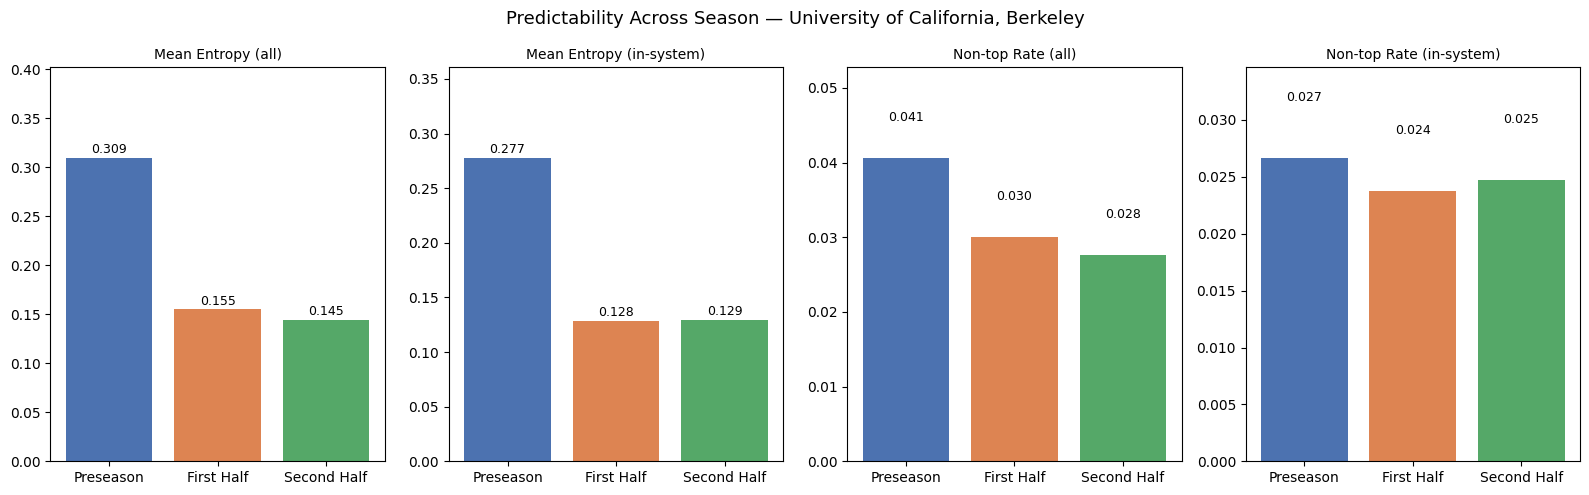

In [28]:
# comparison chart across periods
metrics = {
    'Mean Entropy (all)':       'mean_entropy_all',
    'Mean Entropy (in-system)': 'mean_entropy_insystem',
    'Non-top Rate (all)':       'non_top_rate_all',
    'Non-top Rate (in-system)': 'non_top_rate_insystem',
}

fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5))

for ax, (metric_label, metric_key) in zip(axes, metrics.items()):
    values = [period_summaries[p][metric_key] for p in period_order]
    labels = [period_labels[p] for p in period_order]
    ax.bar(labels, values, color=['#4C72B0', '#DD8452', '#55A868'])
    ax.set_title(metric_label, fontsize=10)
    ax.set_ylim(0, max(values) * 1.3 if max(values) > 0 else 1)
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

fig.suptitle(f"Predictability Across Season — {FOCUS_TEAM}", fontsize=13)
plt.tight_layout()
plt.show()

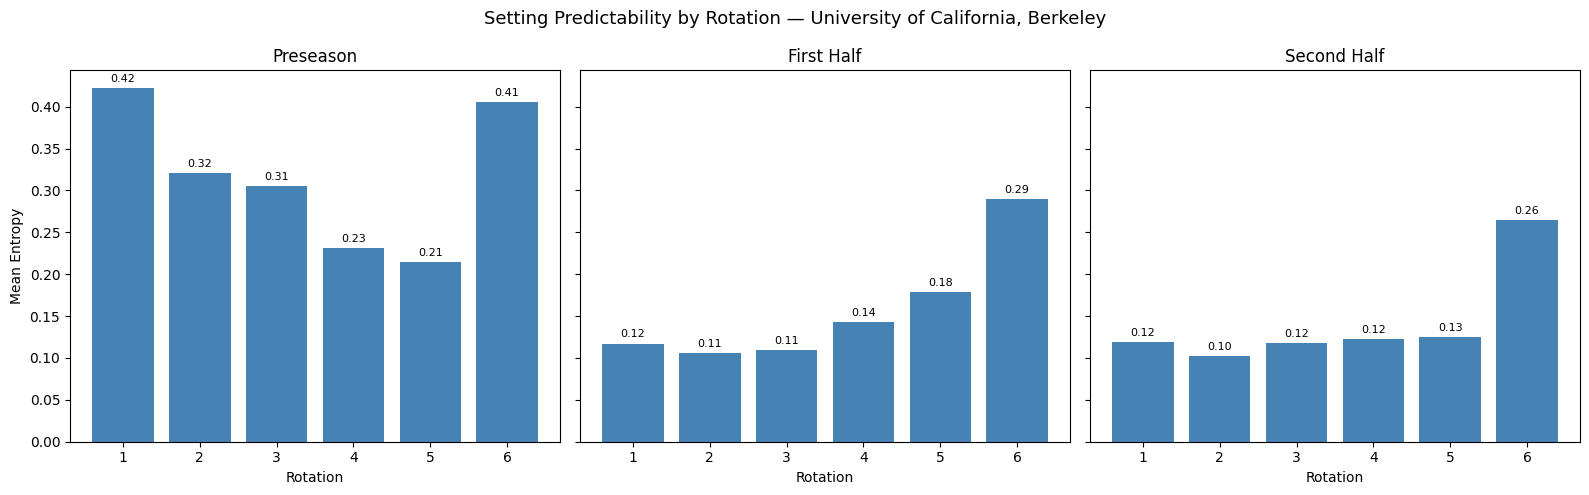

In [29]:
# entropy by rotation across periods
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, period in zip(axes, period_order):
    entropy = period_summaries[period]['entropy_by_rotation'].reindex(range(1, 7))
    bars = ax.bar(range(1, 7), entropy.values, color='steelblue')
    ax.set_title(period_labels[period])
    ax.set_xlabel("Rotation")
    ax.set_ylabel("Mean Entropy" if period == 'pre' else "")
    ax.set_xticks(range(1, 7))
    for bar, val in zip(bars, entropy.values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=8)

fig.suptitle(f"Setting Predictability by Rotation — {FOCUS_TEAM}", fontsize=13)
plt.tight_layout()
plt.show()

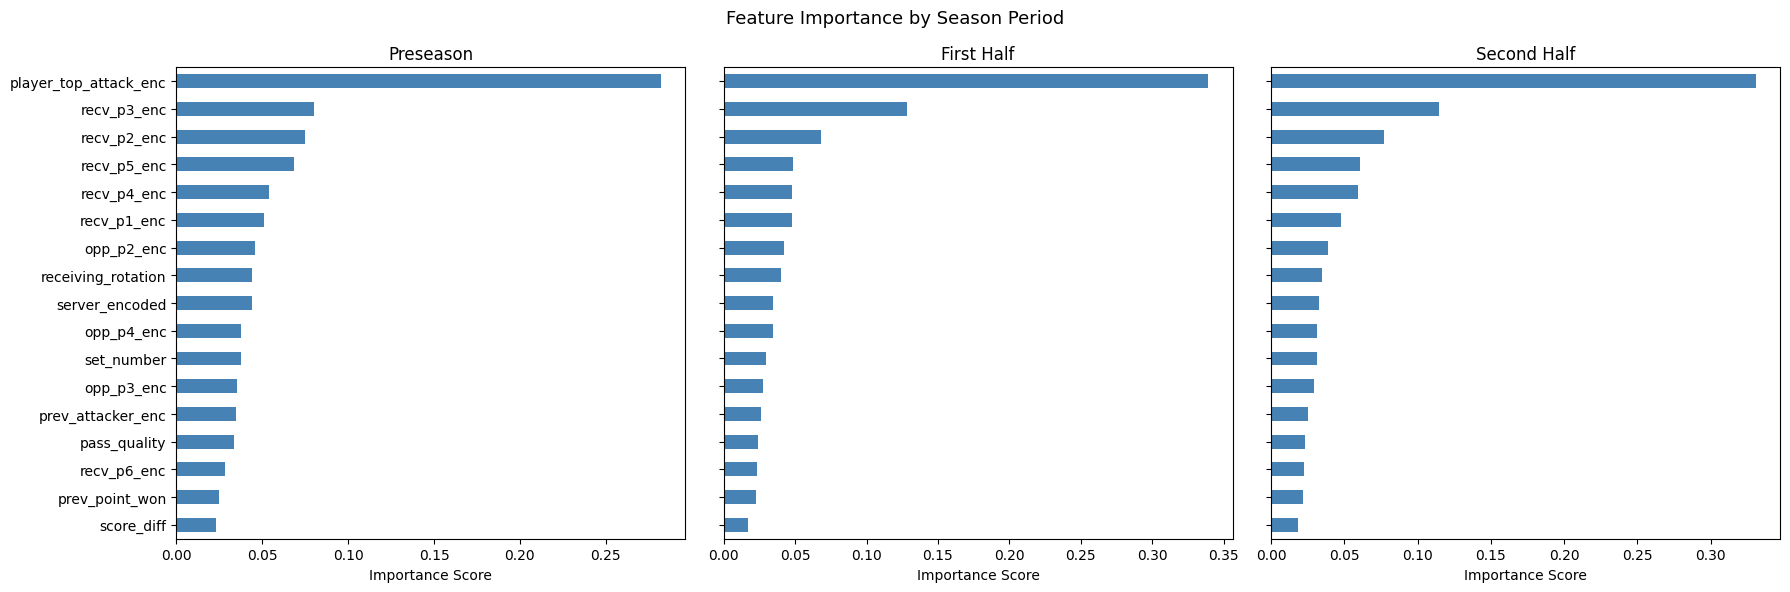

In [32]:
# feature importance across periods
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, period in zip(axes, period_order):
    importances = pd.Series(
        period_models[period].feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(period_labels[period])
    ax.set_xlabel("Importance Score")

fig.suptitle("Feature Importance by Season Period", fontsize=13)
plt.tight_layout()
plt.show()